## Task 1

* Construct a deterministic finite automaton (DFA) that recognizes valid simplified English
words. An English word, for this problem, is defined as a string that:
* Starts with an lowercase letter
* Followed by zero or more lowercase letters
That is, the string must:
* Not start with a digit or punctuation
* Not contain uppercase letters after the first character
* Not contain spaces, digits, or special characters
Output Format:
If a string is accepted, output Accepted else Not Accepted.
* Accepted: cat, dog, a, zebra
Not Accepted: dog1, 1dog, DogHouse, Dog_house, cats (starts with a space)

In [ ]:
# 1. Install the system-level Graphviz development files
!apt-get update
!apt-get install libgraphviz-dev -y

# 2. Install the required Python packages
!pip install pygraphviz coloraide

Hit:1 https://cli.github.com/packages stable InRelease
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [110 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,314 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [4,203 kB]
Get:13 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [10.7 MB]
Get:14 http://archive.u

In [ ]:
pip install automata-lib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.9/84.9 kB 3.3 MB/s eta 0:00:00


In [ ]:
!pip install --force-reinstall automata-lib

  Using cached automata_lib-9.2.0-py3-none-any.whl.metadata (4.9 kB)
  Using cached cached_method-0.1.0-py3-none-any.whl.metadata (2.9 kB)
Using cached automata_lib-9.2.0-py3-none-any.whl (84 kB)
Using cached cached_method-0.1.0-py3-none-any.whl (4.2 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 3.8 MB/s eta 0:00:00
  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.16.0
    Uninstalling typing_extensions-4.16.0:
      Successfully uninstalled typing_extensions-4.16.0
  Attempting uninstall: networkx
    Found existing installation: networkx 3.6.1
    Uninstalling networkx-3.6.1:
      Successfully uninstalled networkx-3.6.1
  Attempting uninstall: frozendict
    Found existing installation: frozendict 2.4.7
    Uninstalling frozendict-2.4.7:
      Successfully uninstalled frozendict-2.4.7
  Attempting uninstall: cached-method
    Found existing instal

In [ ]:
def my_dfa_acccept(word,dfa_info):
  ip_symbol=dfa_info['input_symbols']
  transition=dfa_info['transitions']
  final_states=dfa_info['final_states']
  init_state=dfa_info['initial_state']
  curr_state=init_state
  for c in word:
    if curr_state in transition and c in ip_symbol and c in transition[curr_state]:
      curr_state=transition[curr_state][c]

  if curr_state in final_states:
    return "Accepted"
  else:
    return "Not Accepted"

In [ ]:
def create_dfa_transition(alphabets):
  transitions = {
        'q0': {},
        'q1': {},
        'q_trap': {}
    }
  for ch in alphabets:
      transitions['q_trap'][ch] = 'q_trap'
      if(ord(ch)<=90 and ord(ch)>=65):
        transitions['q0'][ch]='q1'
        transitions['q1'][ch]='q_trap'
      elif(ord(ch)<=122 and ord(ch)>=97):
        transitions['q0'][ch]='q1'
        transitions['q1'][ch]='q1'
      else:
        transitions['q0'][ch]='q_trap'
        transitions['q1'][ch]='q_trap'
        transitions['q_trap'][ch]='q_trap'
  return transitions

In [ ]:
import string

# Printable ASCII characters
printable_ascii = set(string.printable)

print(printable_ascii)


{'l', 'U', '4', 'X', ')', '\\', 'o', 'n', 'z', 'Z', 'e', ',', 'u', 'q', '\n', 'T', 'Q', 'i', ']', '(', '5', 'G', 'v', 'V', '\t', '"', '$', '*', '2', "'", '&', '\x0c', '|', 'h', 'm', '\x0b', ';', 'y', 'L', 'x', 'j', '.', '@', 'R', '~', '^', 'H', '}', '#', 'r', 'a', 's', 'f', ' ', ':', 'p', '%', '/', 'S', '9', 'D', 'E', 'N', '?', 'M', 'O', '1', '<', 'F', '0', '{', 'k', '>', 'K', 'd', 'A', 'b', 'Y', 'B', '6', '\r', '7', '-', '_', 'C', '=', '+', 'w', '[', 'I', 'g', '8', 'P', '!', '`', 'c', 'J', '3', 't', 'W'}


In [ ]:
import string
from automata.fa.dfa import DFA

ip_symbols = set(string.printable)
dfa = DFA(
    states={'q0', 'q1','q_trap'},
    input_symbols=ip_symbols,
    transitions=create_dfa_transition(ip_symbols),
    initial_state='q0',
    final_states={'q1'}
)



dfa_info = {
    'input_symbols': dfa.input_symbols,
    'transitions': dfa.transitions,
    'final_states': dfa.final_states,
    'initial_state': dfa.initial_state
}
dfa.show_diagram()

In [ ]:
dummy_ip="010"
print(my_dfa_acccept(dummy_ip,dfa_info))

Not Accepted


In [ ]:
dummy_ip='A'
print(my_dfa_acccept(dummy_ip,dfa_info))

Accepted


In [ ]:
print(f"'My': {my_dfa_acccept('My', dfa_info)}")
print(f"'mY': {my_dfa_acccept('mY', dfa_info)}")
print(f"'Uma_ng': {my_dfa_acccept('Uma_ng', dfa_info)}")

'My': Accepted
'mY': Not Accepted
'Uma_ng': Not Accepted


## Task 2


* You are given all the nouns from the brown corpus (brown_nouns.txt). You need to
design a finite state transducer (FST) to generate the morph/grammatical features for
every word in the corpus.
* Your output should look like the following:
* foxes = fox+N+PL (can be generalized as root+category+number)
* fox = fox+N+SG [where SG->Singular, PL->Plural, N->Noun]
* You need to take the following properties:

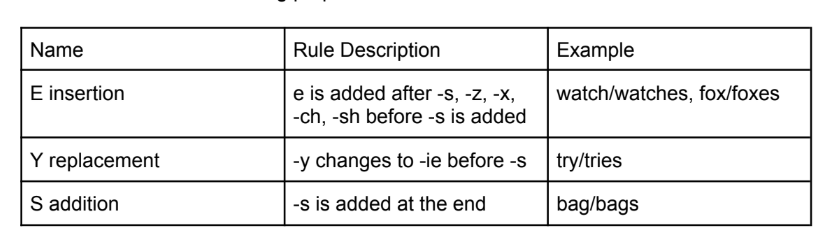

You need to ensure that incorrect words are not generated. You return an output “Invalid
Word” in that case. Example: foxs = “Invalid Word”

There are techniques to decrease the number of states, try implementing them. Bonus
marks for such techniques. [Don’t try to code the rules, need to design an FST with
transition table, input and output alphabets]

In [ ]:
# Install PyPDF2 to extract text from PDF files
!pip install PyPDF2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 5.6 MB/s eta 0:00:00


In [ ]:
import PyPDF2

pdf_path = '/content/brown_nouns.pdf'

# Open the PDF file in binary read mode
with open(pdf_path, 'rb') as file:
    # Create a PDF reader object
    reader = PyPDF2.PdfReader(file)

    # Initialize an empty string to store extracted text
    full_text = []

    # Iterate through all pages and extract text
    for page_num in range(len(reader.pages)):
        page = reader.pages[page_num]
        full_text.append(page.extract_text())

    # Join the extracted text from all pages and split into lines
    all_lines = '\n'.join(full_text).split('\n')

    # Filter out empty lines and get the first 5 non-empty lines
    top_5_lines = [line.strip() for line in all_lines if line.strip()][:5]

    print("Top 5 lines from the PDF:")
    for line in top_5_lines:
        print(line)

Top 5 lines from the PDF:
investigation primary election evidence irregularities place jury presentments charge election
praise thanks manner election term jury reports irregularities primary handful reports jury
interest election number voters size city jury registration election laws legislators laws end jury
number topics departments practices interest governments jury of fices ef ficiency cost
administration jury personnel result city personnel policies city steps problem Implementation


In [ ]:
corpus = [word for line in all_lines for word in line.split()]
print(corpus[:5])


['investigation', 'primary', 'election', 'evidence', 'irregularities']


In [20]:
# 1. Define Transition Rules
fst_transitions = {
    'q0': {
        'reg': [('q0', 'INPUT')],
        'y': [('q0', 'INPUT')],
        'h': [('q0', 'INPUT')],
        'c': [('q_c', 'INPUT')],
        'x': [('q_xz', 'INPUT')],
        'z': [('q_xz', 'INPUT')],
        's': [('q_s', 'INPUT'), ('q_f', '+N+PL')],
        'i': [('q0', 'INPUT'), ('q_ie1', 'y')],
        'e': [('q0', 'INPUT')]
    },
    'q_c': {
        'reg': [('q0', 'INPUT')],
        'h': [('q_xz', 'INPUT')],
        's': [('q_s', 'INPUT'), ('q_f', '+N+PL')],
        'c': [('q_c', 'INPUT')],
        'i': [('q0', 'INPUT'), ('q_ie1', 'y')],
        'e': [('q0', 'INPUT')]
    },
    'q_s': {
        'reg': [('q0', 'INPUT')],
        's': [('q_s', 'INPUT')],
        'e': [('q0', 'INPUT'), ('q_es', 'EPSILON')],
        'i': [('q0', 'INPUT'), ('q_ie1', 'y')]
    },
    'q_xz': {
        'reg': [('q0', 'INPUT')],
        'e': [('q0', 'INPUT'), ('q_es', 'EPSILON')],
        'i': [('q0', 'INPUT'), ('q_ie1', 'y')]
    },
    'q_es':  {'s': [('q_f', '+N+PL')]},
    'q_ie1': {'e': [('q_ie2', 'EPSILON')]},
    'q_ie2': {'s': [('q_f', '+N+PL')]}
}



In [22]:
def get_char_key(char):
    """Maps characters explicitly to avoid group overlapping bugs."""
    if char in {'c', 'h', 's', 'z', 'x', 'y', 'e', 'i'}:
        return char
    return 'reg'

In [23]:
def process_fst_fixed(surface_word):
    # Normalize to lowercase to handle capitalized PDF extractions
    surface_word = surface_word.lower()
    active_paths = [('q0', "")]

    for char in surface_word:
        char_key = get_char_key(char)
        next_paths = []

        for state, current_output in active_paths:
            # Get transitions for current state, default to empty list if none exist
            transitions = fst_transitions.get(state, {}).get(char_key, [])

            for next_state, output_action in transitions:
                if output_action == 'INPUT':
                    new_output = current_output + char
                elif output_action == 'EPSILON':
                    new_output = current_output
                else:
                    new_output = current_output + output_action

                next_paths.append((next_state, new_output))

        active_paths = next_paths

        # If all branches die, the string violates phonotactics (e.g., "foxs")
        if not active_paths:
            return "Invalid Word"

    # --- Evaluation Logic ---
    valid_plurals = []
    valid_singulars = []

    for state, output in active_paths:
        if state == 'q_f':
            valid_plurals.append(output)
        elif state in {'q0', 'q_c', 'q_s', 'q_xz'}:
            valid_singulars.append(output + "+N+SG")

    # Prioritize Plurals, picking the shortest length to enforce special rules
    if valid_plurals:
        return sorted(valid_plurals, key=len)[0]

    # Fallback to Singulars
    if valid_singulars:
        return sorted(valid_singulars, key=len)[0]

    return "Invalid Word"

In [25]:
print("--- FST Morphological Analysis ---")
print("-" * 40)

for word in corpus[:100]:
    if word.isalpha():
        result = process_fst_fixed(word)
        print(f"{word:<15} -> {result}")

--- FST Morphological Analysis ---
----------------------------------------
investigation   -> investigation+N+SG
primary         -> primary+N+SG
election        -> election+N+SG
evidence        -> evidence+N+SG
irregularities  -> irregularity+N+PL
place           -> place+N+SG
jury            -> jury+N+SG
presentments    -> presentment+N+PL
charge          -> charge+N+SG
election        -> election+N+SG
praise          -> praise+N+SG
thanks          -> thank+N+PL
manner          -> manner+N+SG
election        -> election+N+SG
term            -> term+N+SG
jury            -> jury+N+SG
reports         -> report+N+PL
irregularities  -> irregularity+N+PL
primary         -> primary+N+SG
handful         -> handful+N+SG
reports         -> report+N+PL
jury            -> jury+N+SG
interest        -> interest+N+SG
election        -> election+N+SG
number          -> number+N+SG
voters          -> voter+N+PL
size            -> size+N+SG
city            -> city+N+SG
jury            -> jury+N+SG
reg

In [ ]:
words_to_test = ["foxes", " fox", "flies", "bags", "foxs", "coin"]

for word in words_to_test:
    result = process_fst(word)
    print(f"{word:<10} -> {result}")

foxes      -> foxe+N+PL
 fox       ->  fox+N+SG
flies      -> flie+N+PL
bags       -> bag+N+PL
foxs       -> Invalid Word
coin       -> coin+N+SG


In [ ]:
for word in corpus[:100]:
    result = process_fst(word)
    print(f"{word:<10} -> {result}")

investigation -> investigation+N+SG
primary    -> primary+N+SG
election   -> election+N+SG
evidence   -> evidence+N+SG
irregularities -> irregularitie+N+PL
place      -> place+N+SG
jury       -> jury+N+SG
presentments -> presentment+N+PL
charge     -> charge+N+SG
election   -> election+N+SG
praise     -> praise+N+SG
thanks     -> thank+N+PL
manner     -> manner+N+SG
election   -> election+N+SG
term       -> term+N+SG
jury       -> jury+N+SG
reports    -> report+N+PL
irregularities -> irregularitie+N+PL
primary    -> primary+N+SG
handful    -> handful+N+SG
reports    -> report+N+PL
jury       -> jury+N+SG
interest   -> interest+N+SG
election   -> election+N+SG
number     -> number+N+SG
voters     -> voter+N+PL
size       -> size+N+SG
city       -> city+N+SG
jury       -> jury+N+SG
registration -> registration+N+SG
election   -> election+N+SG
laws       -> law+N+PL
legislators -> legislator+N+PL
laws       -> law+N+PL
end        -> end+N+SG
jury       -> jury+N+SG
number     -> number+N+